## The HR diagram   (...and the importance of data scaling in machine learning)

This assignment is about stars... We will work with a star catalogue of 240 stars described by the following information:

- Temperature (in Kelvin)
- Luminosity (L/Lo) (relativo alla luminosità del sole)
- Radius (R/Ro) (relativo al raggio del sole)
- Absolute magnitude (Mv)

We also have the following data for each star:

- Color (Red/Orange/Yellow/White/Blue)
- Spectral class ('A', 'B', 'F', 'G', 'K', 'M', 'O')
- Star type (Brown dwarf/Red dwarf/White dwarf/Main sequence/Supergiant/Hypergiant)

This dataset has been collected by [Deepraj Baidya](https://github.com/deepraj1729) and was originally published on [Kaggle](https://www.kaggle.com/deepu1109/star-dataset). 

In [302]:
import urllib.request
import pandas as pd
import numpy as np
import pylab as plt
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x23d9dca3da0>)

In [303]:
df_stars = pd.read_csv("stars.csv")

In [304]:
print(df_stars)
#ho 240 stelle e 7 colonne, in realtà solo le prime 4 sono colonne "quantitative". Le ultime tre sono stringhe ma sono più comode se le trasformiamo in 
#int
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
#Brown Dwarf -> Star Type = 0
#Red Dwarf -> Star Type = 1
#White Dwarf-> Star Type = 2
#Main Sequence -> Star Type = 3
#Supergiant -> Star Type = 4
#Hypergiant -> Star Type = 5

df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)

     Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  Absolute magnitude(Mv)  \
0               3068          0.002400        0.1700                   16.12   
1               3042          0.000500        0.1542                   16.60   
2               2600          0.000300        0.1020                   18.70   
3               2800          0.000200        0.1600                   16.65   
4               1939          0.000138        0.1030                   20.06   
..               ...               ...           ...                     ...   
235            38940     374830.000000     1356.0000                   -9.93   
236            30839     834042.000000     1194.0000                  -10.63   
237             8829     537493.000000     1423.0000                  -10.73   
238             9235     404940.000000     1112.0000                  -11.23   
239            37882     294903.000000     1783.0000                   -7.80   

       Star type Star color Spectral Cl

In [305]:
#Ci sono valori mancanti o NaNs? Teoricamente no perché nel dataset c'è scritto 
#"The missing data were manually calculated using those equations of astrophysics given above."
#Però controlliamo!
df_stars.isna().any().any()

np.False_

Facciamo ora un diagramma di Hertzsprung-Russell, ovvero plottiamo temperatura e luminosità. Questo dovrebbe darci una classificazione delle stelle

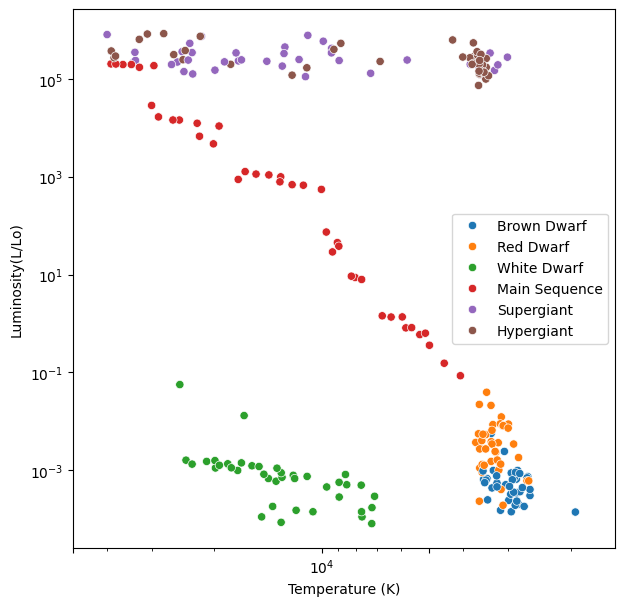

In [306]:
import seaborn as sns
fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels)

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

Già da questo plot si nota che le White Dwarves sono molto separate dalle altre, idem per la main sequence che ha una forma contraddistinta. Mentre le brown dwarves e le red dwarves sono nello stesso punto, così come le supergiant e le hypergiant. Ci servono altre variabili per distinguere queste due coppie di stelle. Usiamo la PCA

In [307]:
from sklearn.decomposition import PCA
X = df_stars[['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)']].values
#abbiamo preso solo i dati quantitativi e non stringhe di testo o int

print(X.shape) #giusto, è NxK, ovvero 240x4

(240, 4)


Proviamo a fare un PCA senza rescalare i dati

In [308]:
pca_test = PCA(n_components=2)
X_test= pca_test.fit_transform(X);
for i, var in enumerate(pca_test.explained_variance_ratio_):
    print(f"PC{i+1} spiega il: {var*100:.2f}% della varianza")

var_accumulata_2d = sum(pca_test.explained_variance_ratio_[:2]) * 100
print(f"\nLe prime 2 componenti insieme spiegano il: {var_accumulata_2d:.2f}% della varianza totale")

PC1 spiega il: 99.76% della varianza
PC2 spiega il: 0.24% della varianza

Le prime 2 componenti insieme spiegano il: 100.00% della varianza totale


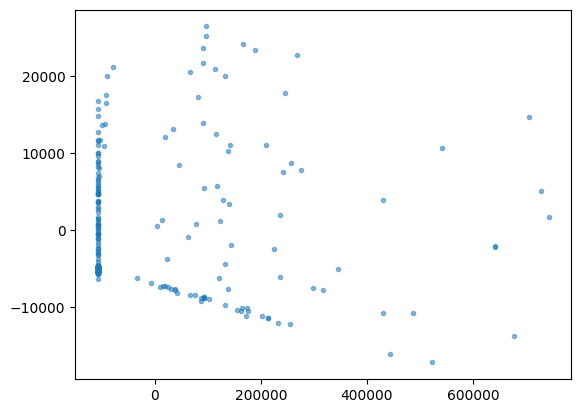

In [309]:
plt.scatter(X_test[:,0], X_test[:,1], 
            marker=".", 
            alpha=0.5)

CVD: bisogna scalare in un ipercubo. I dati sono in unità troppo differenti. Difatti in questo modo la prima componente spiega il 99.76% della varianza totale, la temperatura è nell'ordine dei 1e3, mentre le altre feature sono nell'ordine 1e-3, 1e-1, 1e1.

In [310]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=3)
X_PCA = pca.fit_transform(X_scaled)
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1} spiega il: {var*100:.2f}% della varianza")

var_accumulata_2d = sum(pca.explained_variance_ratio_[:3]) * 100
print(f"\nLe prime 3 componenti insieme spiegano il: {var_accumulata_2d:.2f}% della varianza totale")

print(X_PCA.shape)

PC1 spiega il: 60.36% della varianza
PC2 spiega il: 23.50% della varianza
PC3 spiega il: 9.33% della varianza

Le prime 3 componenti insieme spiegano il: 93.19% della varianza totale
(240, 3)


Con due componenti spiego l'83% della varianza, con 3 componenti il 93%. Lo StandardScaler si è occupato di fare centering e il whitening dei dati

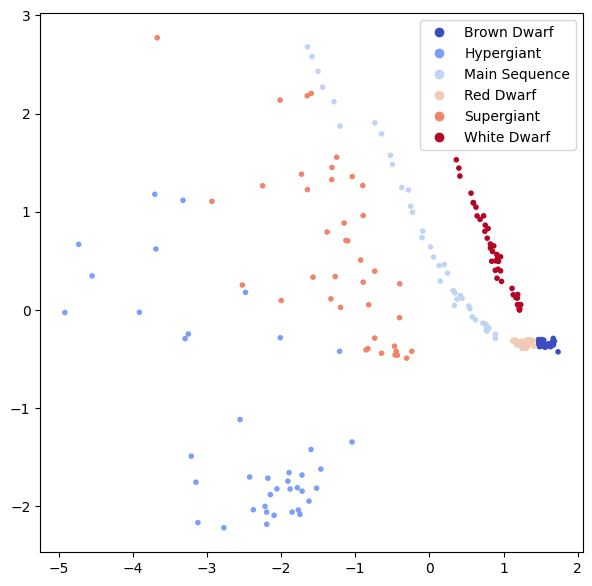

In [320]:
fig = plt.figure(figsize=(7, 7))
scatter =plt.scatter(X_PCA[:,0], X_PCA[:,1], marker=".", alpha=1, c = df_stars['Star type'], cmap = 'coolwarm')

handles, _ = scatter.legend_elements()

plt.legend(handles, class_names)

#Brown dwarves-red dwarves,  supergiant-hypergiant. 


Le brown/red sono ancora piuttosto vicine anche se distinte, mentre le hsupergiant e le hyper giant risultano ben distinte

### Part 2. [Optional, not examinable]
- Now run a supervised classification algorithm on this dataset. 
- Can you predict the stellar type? How well? Careful with overfitting of course.

Tentativo prima della lezione 20 come suggerito dal notebook: Uso lo stesso approccio dell'Ex10 sulle handwritten digit, con il Logistic Regression

In [316]:
y = df_stars['Star type'].values
print(y)

[0 0 0 0 0 0 0 0 0 0 3 3 3 3 3 3 3 3 3 3 5 5 5 5 5 5 5 5 5 5 2 2 2 2 2 2 2
 2 2 2 4 4 4 4 4 4 4 4 4 4 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 3 3 3 3
 3 3 3 3 3 3 5 5 5 5 5 5 5 5 5 5 2 2 2 2 2 2 2 2 2 2 4 4 4 4 4 4 4 4 4 4 1
 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 3 3 3 3 3 3 3 3 3 3 5 5 5 5 5 5 5 5
 5 5 2 2 2 2 2 2 2 2 2 2 4 4 4 4 4 4 4 4 4 4 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0
 0 0 0 0 0 3 3 3 3 3 3 3 3 3 3 5 5 5 5 5 5 5 5 5 5 2 2 2 2 2 2 2 2 2 2 4 4
 4 4 4 4 4 4 4 4 1 1 1 1 1 1 1 1 1 1]


In [317]:
import sklearn
Xtrain, Xtest, ytrain, ytest = sklearn.model_selection.train_test_split(X_PCA, y, test_size = 0.33, random_state = 42)
lr = sklearn.linear_model.LogisticRegression(solver='sag', max_iter=5000)
lr.fit(Xtrain, ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [318]:

ypred = lr.predict(Xtest)

print(f"Accuracy score: {sklearn.metrics.accuracy_score(ytest,ypred)}")

print(class_names)

print(f"{sklearn.metrics.confusion_matrix(ytest, ypred)}")

Accuracy score: 0.9375
['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']
[[16  0  0  0  0  0]
 [ 0 16  0  0  0  0]
 [ 0  0  8  2  1  0]
 [ 1  0  0 12  0  0]
 [ 0  0  1  0 11  0]
 [ 0  0  0  0  0 12]]


Abbiamo ottenuto un accuracy score dell'85%. Vediamo come sono distribuiti gli errori nel grafico.

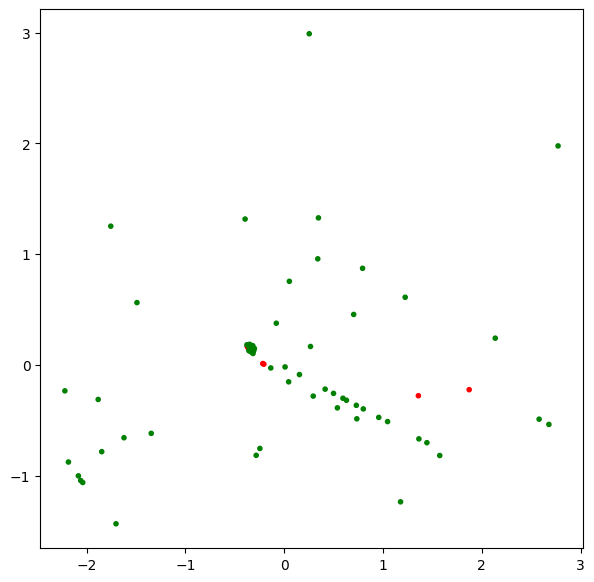

In [321]:
fig = plt.figure(figsize=(7, 7))
colors = np.where(ytest == ypred, 'green', 'red')
plt.scatter(Xtest[:,1], Xtest[:,2], marker=".", c = colors)